# 04 — Model Evaluation & Residual Analysis

Deep dive into how well each model performs and WHERE it fails.

**Residual = actual price minus predicted price**
- If residual is close to 0 = good prediction
- Positive residual = model underpredicted
- Negative residual = model overpredicted

We look for PATTERNS in errors — if errors are systematic in one area
(e.g. always wrong for luxury listings), the model has a bias there.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib         import Path

MODELS_DIR = Path('../models')
REPORTS    = Path('../../reports')

BLUE  = '#185FA5'
TEAL  = '#1D9E75'
RED   = '#A32D2D'
AMBER = '#BA7517'

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

model_df = pd.read_parquet('../../data/processed/model_ready.parquet')
df=pd.read_parquet('../../data/processed/ml_prepared.parquet')
with open('../../data/processed/feature_list.json') as f:
    FEATURES = json.load(f)

X = model_df[FEATURES]
y = model_df['log_price']

# Load all 3 models
loaded_models = {}
for name, filename in [
    ('Ridge Regression', 'ridge_regression.pkl'),
    ('Random Forest',    'random_forest.pkl'),
    ('XGBoost',          'xgboost.pkl'),
]:
    path = MODELS_DIR / filename
    if path.exists():
        with open(path, 'rb') as f:
            loaded_models[name] = pickle.load(f)
        print(f'Loaded {name}')

print(f'\nModels loaded: {list(loaded_models.keys())}')

Loaded Ridge Regression
Loaded Random Forest
Loaded XGBoost

Models loaded: ['Ridge Regression', 'Random Forest', 'XGBoost']


In [15]:
# Generate predictions for all models
predictions = {}
for name, model in loaded_models.items():
    y_pred_log   = model.predict(X)
    y_pred_real  = np.expm1(y_pred_log)
    y_real       = np.expm1(y)
    residuals    = y_real.values - y_pred_real

    mae  = mean_absolute_error(y_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred_real))
    mape = np.mean(np.abs(residuals / y_real.clip(lower=1))) * 100

    predictions[name] = {
        'y_pred'   : y_pred_real,
        'residuals': residuals,
        'MAE'      : mae,
        'RMSE'     : rmse,
        'MAPE'     : mape,
    }
    print(f'{name:<20}: MAE=€{mae:.1f}  RMSE=€{rmse:.1f}  MAPE={mape:.1f}%')

# Use best model for residual analysis
best_name  = min(predictions, key=lambda x: predictions[x]['MAE'])
best_preds = predictions[best_name]
print(f'\nUsing {best_name} for detailed residual analysis')

Ridge Regression    : MAE=€156.0  RMSE=€1991.5  MAPE=31.7%
Random Forest       : MAE=€136.1  RMSE=€1965.0  MAPE=24.1%
XGBoost             : MAE=€81.9  RMSE=€1075.6  MAPE=19.6%

Using XGBoost for detailed residual analysis


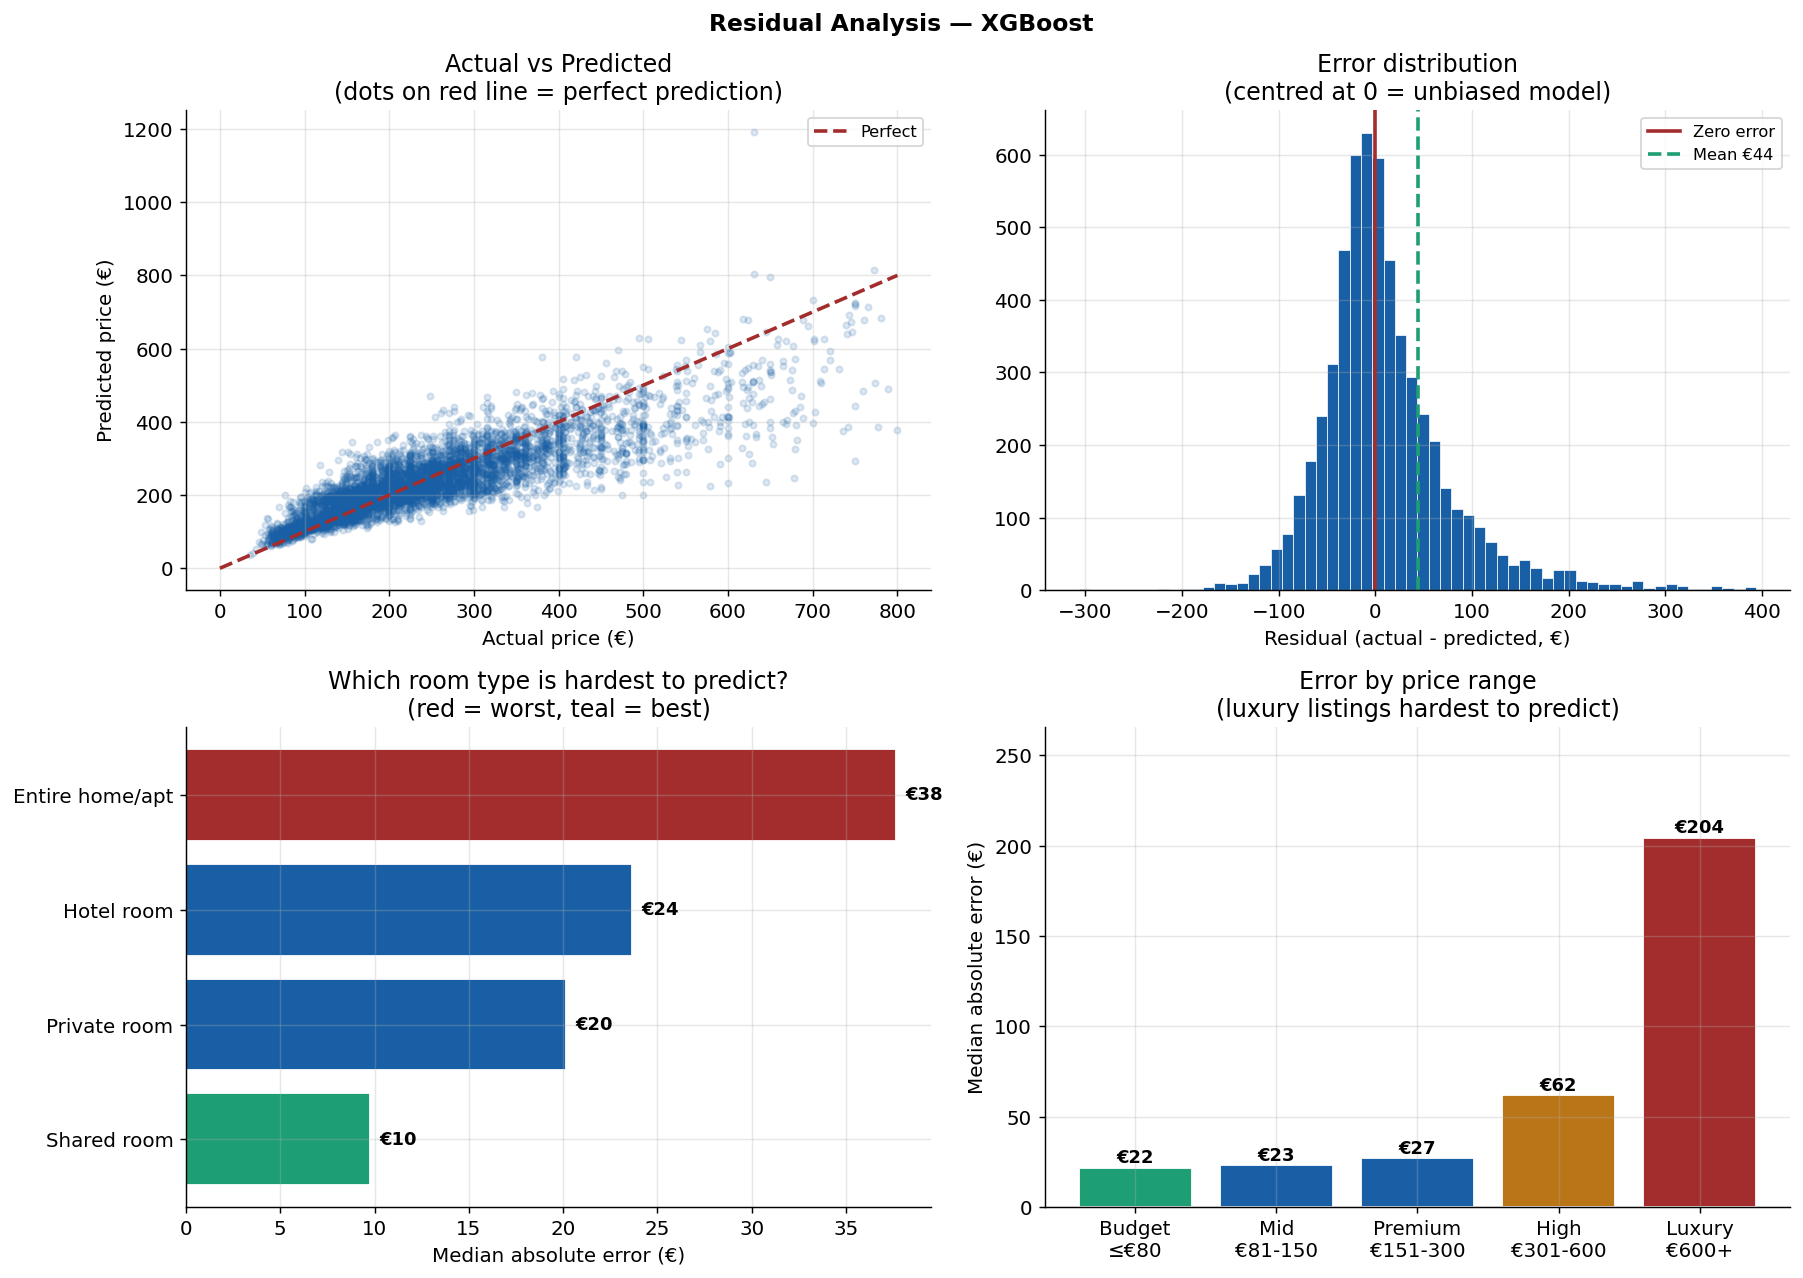


Residual Analysis Summary:
  Mean error    : €44.0  (close to 0 = unbiased overall)
  Std of errors : €1074.7

  Budget and mid-range listings predict best — these have the most
  training examples and follow predictable patterns.

  Luxury listings have large errors because they have unique features
  (canal views, heritage buildings, rare amenities) that are not
  captured in the structured data columns.

  This is expected. The model is designed for typical listings,
  not for pricing rare luxury properties.



In [16]:
y_real     = np.expm1(y.values)
y_pred     = best_preds['y_pred']
residuals  = best_preds['residuals']

#eval_df    = model_df[['price','room_type','neighbourhood_cleansed']].copy()
eval_df = df.loc[model_df.index,
                 ['price',
                  'room_type',
                  'neighbourhood_cleansed']].copy()
eval_df['predicted']  = y_pred
eval_df['residual']   = residuals
eval_df['abs_error']  = np.abs(residuals)
eval_df['pct_error']  = np.abs(residuals / eval_df['price'].clip(lower=1)) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Residual Analysis — {best_name}', fontsize=13, fontweight='bold')

# ── Chart 1: Actual vs Predicted ─────────────────────────────
ax = axes[0, 0]
cap = 800
mask = y_real <= cap
ax.scatter(y_real[mask], y_pred[mask], alpha=0.15, color=BLUE, s=12)
ax.plot([0,cap],[0,cap], color=RED, linewidth=2, linestyle='--', label='Perfect')
ax.set_xlabel('Actual price (€)')
ax.set_ylabel('Predicted price (€)')
ax.set_title('Actual vs Predicted\n(dots on red line = perfect prediction)')
ax.legend(fontsize=9)

# ── Chart 2: Residual distribution ────────────────────────────
ax2 = axes[0, 1]
clip_res = residuals[np.abs(residuals) <= 400]
ax2.hist(clip_res, bins=60, color=BLUE, edgecolor='white', linewidth=0.4)
ax2.axvline(0,               color=RED,  linewidth=2, label='Zero error')
ax2.axvline(residuals.mean(),color=TEAL, linewidth=2, linestyle='--',
            label=f'Mean €{residuals.mean():.0f}')
ax2.set_xlabel('Residual (actual - predicted, €)')
ax2.set_title('Error distribution\n(centred at 0 = unbiased model)')
ax2.legend(fontsize=9)

# ── Chart 3: Error by room type ───────────────────────────────
ax3 = axes[1, 0]
room_err = eval_df.groupby('room_type')['abs_error'].median().sort_values()
cols     = [TEAL if v == room_err.min() else
            (RED if v == room_err.max() else BLUE) for v in room_err]
bars = ax3.barh(room_err.index, room_err.values, color=cols, edgecolor='white')
for bar, val in zip(bars, room_err.values):
    ax3.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'€{val:.0f}', va='center', fontsize=10, fontweight='bold')
ax3.set_xlabel('Median absolute error (€)')
ax3.set_title('Which room type is hardest to predict?\n(red = worst, teal = best)')

# ── Chart 4: Error by price range ────────────────────────────
ax4 = axes[1, 1]
eval_df['bucket'] = pd.cut(eval_df['price'],
    bins=[0,80,150,300,600,50000],
    labels=['Budget\n≤€80','Mid\n€81-150','Premium\n€151-300',
            'High\n€301-600','Luxury\n€600+'])
range_err = eval_df.groupby('bucket', observed=True)['abs_error'].median()
colors_p  = [TEAL, BLUE, BLUE, AMBER, RED]

bars2 = ax4.bar(range_err.index.astype(str), range_err.values,
                color=colors_p[:len(range_err)], edgecolor='white')
for bar, val in zip(bars2, range_err.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'€{val:.0f}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)
ax4.set_ylabel('Median absolute error (€)')
ax4.set_title('Error by price range\n(luxury listings hardest to predict)')
ax4.set_ylim(0, range_err.max() * 1.3)

plt.tight_layout()
plt.savefig(REPORTS / 'fig_ml_residuals.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"""
Residual Analysis Summary:
  Mean error    : €{residuals.mean():.1f}  (close to 0 = unbiased overall)
  Std of errors : €{residuals.std():.1f}

  Budget and mid-range listings predict best — these have the most
  training examples and follow predictable patterns.

  Luxury listings have large errors because they have unique features
  (canal views, heritage buildings, rare amenities) that are not
  captured in the structured data columns.

  This is expected. The model is designed for typical listings,
  not for pricing rare luxury properties.
""")

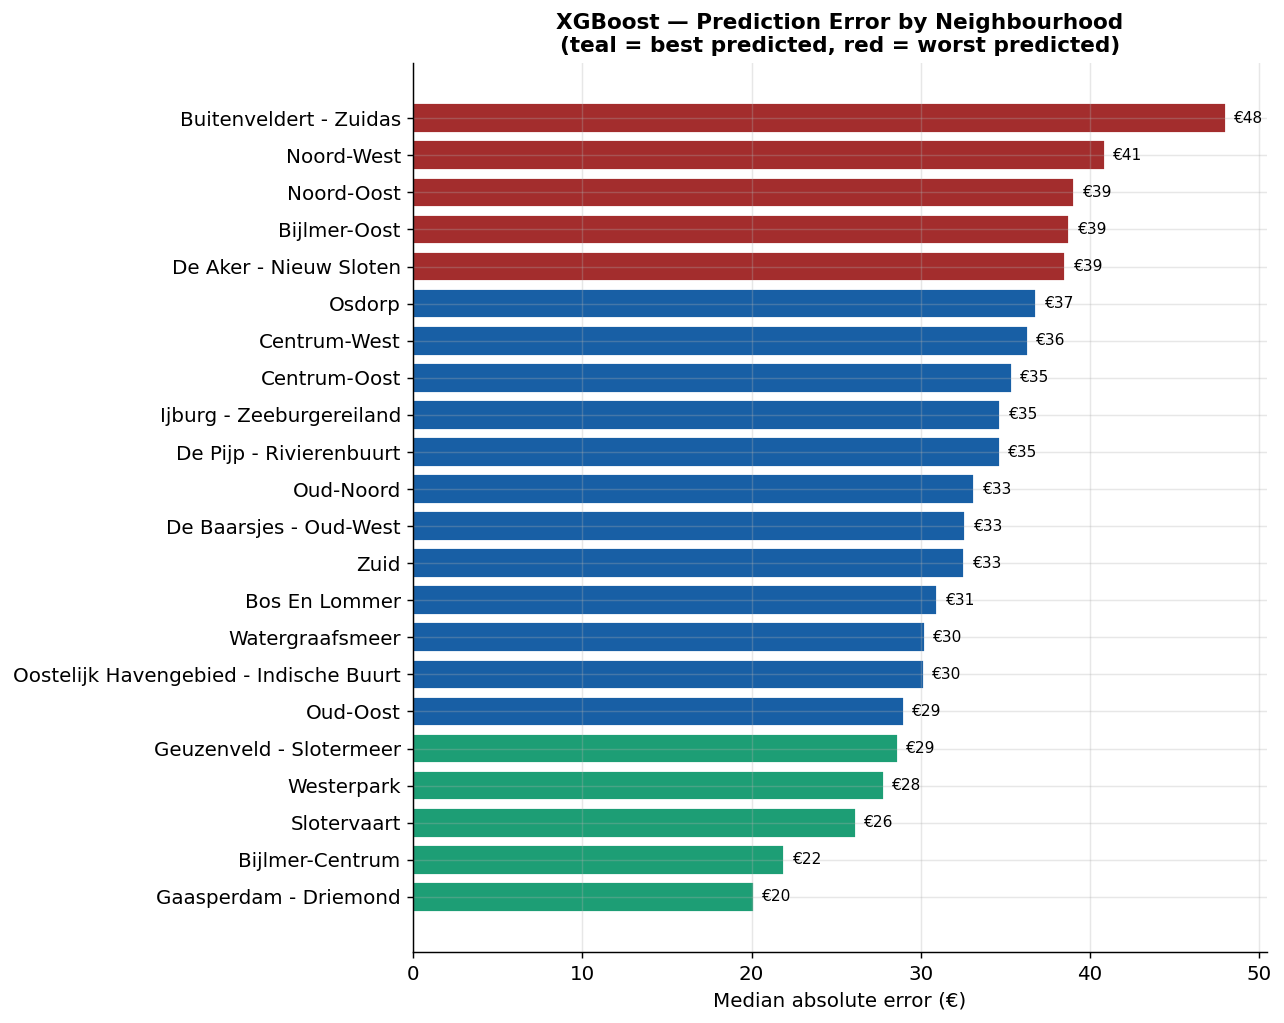

Best predicted neighbourhoods (lowest error):
 neighbourhood_cleansed  median_error  count
  Gaasperdam - Driemond     20.118557     30
        Bijlmer-Centrum     21.918854     35
            Slotervaart     26.145401    100
             Westerpark     27.808258    391
Geuzenveld - Slotermeer     28.636368     91

Hardest to predict (highest error):
neighbourhood_cleansed  median_error  count
De Aker - Nieuw Sloten     38.552292     42
          Bijlmer-Oost     38.772896     22
            Noord-Oost     39.090576    127
            Noord-West     40.892578    175
Buitenveldert - Zuidas     48.055611     82


In [17]:
# Error by neighbourhood — which areas does the model struggle with?
nbh_errors = (eval_df.groupby('neighbourhood_cleansed')
              .agg(median_error=('abs_error','median'),
                   count=('abs_error','count'))
              .sort_values('median_error', ascending=True)
              .reset_index())

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = [TEAL if i < 5 else (RED if i >= len(nbh_errors)-5 else BLUE)
              for i in range(len(nbh_errors))]
bars = ax.barh(nbh_errors['neighbourhood_cleansed'],
               nbh_errors['median_error'],
               color=bar_colors, edgecolor='white')
for bar, val in zip(bars, nbh_errors['median_error']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'€{val:.0f}', va='center', fontsize=8.5)
ax.set_xlabel('Median absolute error (€)')
ax.set_title(f'{best_name} — Prediction Error by Neighbourhood\n'
             '(teal = best predicted, red = worst predicted)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'fig_ml_error_by_neighbourhood.png',
            dpi=130, bbox_inches='tight')
plt.show()

print('Best predicted neighbourhoods (lowest error):')
print(nbh_errors.head(5)[['neighbourhood_cleansed','median_error','count']].to_string(index=False))
print('\nHardest to predict (highest error):')
print(nbh_errors.tail(5)[['neighbourhood_cleansed','median_error','count']].to_string(index=False))